# Feature Engineering Lab

**目的**: 特徴量を変更し、全モデルを一括で回してロバスト性を確認する。

**使い方**:
1. `make_exp_builder()` のパラメータを切り替えて特徴量セットを構成
2. **Run All** で全モデルの CV AUC を一覧比較
3. ベースライン (v1) との差分が全モデルで改善していればロバスト

**leak-free**: `make_exp_builder()` により、CVの各foldでtrain分割のみから統計量を計算する。

**プリセット**: `EXP_PRESETS["minimal"]` / `"recommended"` / `"kitchen_sink"`

## 0. Setup

In [ ]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.config import TRAIN_CSV, TEST_CSV, SAMPLE_SUBMIT_CSV, SEED, N_FOLDS, TARGET_COL
from src.utils import seed_everything
from src.features import compute_train_stats, build_pipeline, make_feature_builder, get_feature_columns
from src.exp_features import make_exp_builder, EXP_PRESETS
from src.evaluation import cross_validate

seed_everything(SEED)

with open("../../configs/default.yaml") as f:
    config = yaml.safe_load(f)

## 1. Data Loading

In [ ]:
train_raw = pd.read_csv(TRAIN_CSV, index_col=0)
test_raw = pd.read_csv(TEST_CSV, index_col=0)

y = train_raw[TARGET_COL]
X_raw = train_raw.drop(columns=[TARGET_COL])

print(f"Train: {X_raw.shape}, Test: {test_raw.shape}")

## 2. Feature Builder (leak-free)

`make_exp_builder()` は CV の各 fold 内で train 分割のみから統計量を計算する。
パラメータを切り替えるだけで特徴量の組み合わせを実験可能。

**プリセット**: `EXP_PRESETS["minimal"]` / `"recommended"` / `"kitchen_sink"`

In [ ]:
# =============================================================
# ★ 特徴量設定 — フラグを切り替えて実験する ★
# =============================================================
# プリセット: "minimal" / "recommended" / "kitchen_sink"
# fb_exp = make_exp_builder(**EXP_PRESETS["recommended"])

fb_exp = make_exp_builder(
    missing_flags=True,       # 欠損フラグ (age_missing, fare_missing, embarked_missing)
    age_bins="rule",          # 年齢ビニング ("rule" / "quantile" / None)
    fare_bins="quantile",     # 運賃ビニング ("quantile" / None)
    interactions=True,        # 交互作用 (age*pclass, fare*pclass, sex*pclass等)
    polynomial=False,         # 多項式 (age^2, fare^2, age*fare)
    group_stats=True,         # グループ統計量 (集団中央値との差分, z-score)
    freq_encoding=False,      # 頻度エンコーディング (pclass出現頻度)
    rank_features=False,      # ランク特徴量 (pclass内fare順位)
    domain_features=True,     # ドメイン特徴量 (is_child, is_mother等)
)

# Baseline: v1 そのまま (leak-free CV)
fb_base = make_feature_builder(version="v1")

# 確認: 追加された特徴量を表示
_sample_tr, _ = fb_exp(X_raw.iloc[:10], X_raw.iloc[10:20])
_base_cols = set(get_feature_columns("v1"))
_new_cols = sorted(set(_sample_tr.columns) - _base_cols)
print(f"Base features:  {len(_base_cols)} cols")
print(f"Exp features:   {len(_sample_tr.columns)} cols (+{len(_new_cols)} new)")
print(f"New features:   {_new_cols}")
del _sample_tr, _, _base_cols, _new_cols

## 3. Model Definitions

In [5]:
def get_models(cfg):
    """Return dict of model_name -> model_fn."""
    models = {}

    models["LogReg"] = lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=cfg["logistic_regression"]["C"],
            penalty=cfg["logistic_regression"]["penalty"],
            solver=cfg["logistic_regression"]["solver"],
            max_iter=cfg["logistic_regression"]["max_iter"],
            random_state=SEED,
        ))
    ])

    models["RF"] = lambda: RandomForestClassifier(**cfg["random_forest"])

    models["XGB"] = lambda: XGBClassifier(**cfg["xgboost"])

    models["LGBM"] = lambda: LGBMClassifier(**cfg["lightgbm"])

    models["Voting"] = lambda: VotingClassifier(
        estimators=[
            ("logreg", models["LogReg"]()),
            ("rf", models["RF"]()),
            ("xgb", models["XGB"]()),
            ("lgbm", models["LGBM"]()),
        ],
        voting="soft",
    )

    return models

models = get_models(config)
print(f"Models: {list(models.keys())}")

Models: ['LogReg', 'RF', 'XGB', 'LGBM', 'Voting']


## 4. Cross-Validation: Baseline vs Experiment

In [ ]:
from time import time

def run_all_models(models, X, y, label="", feature_builder=None):
    """Run CV for all models, return results dict."""
    results = {}
    for name, model_fn in models.items():
        t0 = time()
        fold_metrics, mean_metrics = cross_validate(
            model_fn, X, y, feature_builder=feature_builder,
        )
        elapsed = time() - t0
        results[name] = mean_metrics
        auc = mean_metrics.get("auc", float("nan"))
        acc = mean_metrics["accuracy"]
        print(f"  {label} {name:8s}: AUC={auc:.4f}  Acc={acc:.4f}  ({elapsed:.1f}s)")
    return results

print("=== Baseline (v1, leak-free) ===")
results_base = run_all_models(models, X_raw, y, label="[base]", feature_builder=fb_base)

print("\n=== Experiment (leak-free) ===")
results_exp = run_all_models(models, X_raw, y, label="[exp] ", feature_builder=fb_exp)

## 5. Results Comparison

In [7]:
df_base = pd.DataFrame(results_base).T.add_suffix("_base")
df_exp = pd.DataFrame(results_exp).T.add_suffix("_exp")
df_cmp = pd.concat([df_base, df_exp], axis=1)

# AUC diff
if "auc_base" in df_cmp.columns and "auc_exp" in df_cmp.columns:
    df_cmp["auc_diff"] = df_cmp["auc_exp"] - df_cmp["auc_base"]
    df_cmp["acc_diff"] = df_cmp["accuracy_exp"] - df_cmp["accuracy_base"]
    sort_col = "auc_diff"
else:
    df_cmp["acc_diff"] = df_cmp["accuracy_exp"] - df_cmp["accuracy_base"]
    sort_col = "acc_diff"

# Display
show_cols = [c for c in ["auc_base", "auc_exp", "auc_diff", "accuracy_base", "accuracy_exp", "acc_diff"] if c in df_cmp.columns]
df_show = df_cmp[show_cols].sort_values(sort_col, ascending=False)
display(df_show.style.format("{:.4f}").background_gradient(subset=[sort_col], cmap="RdYlGn"))

# Summary
if "auc_diff" in df_cmp.columns:
    improved = (df_cmp["auc_diff"] > 0).sum()
    total = len(df_cmp)
    mean_diff = df_cmp["auc_diff"].mean()
    print(f"\nAUC improved in {improved}/{total} models (mean diff: {mean_diff:+.4f})")
    if improved == total:
        print(">>> ALL MODELS IMPROVED — robust feature engineering!")
    elif improved == 0:
        print(">>> NO IMPROVEMENT — revert or rethink the features.")
    else:
        print(">>> MIXED RESULTS — feature may help some models but not others.")

,auc_base,auc_exp,auc_diff,accuracy_base,accuracy_exp,acc_diff
LogReg,0.8536,0.8536,0.0000,0.8000,0.8000,0.0000
RF,0.8603,0.8603,0.0000,0.8045,0.8045,0.0000
XGB,0.8561,0.8561,0.0000,0.8000,0.8000,0.0000
LGBM,0.8429,0.8429,0.0000,0.7865,0.7865,0.0000
Voting,0.8639,0.8639,0.0000,0.8000,0.8000,0.0000



AUC improved in 0/5 models (mean diff: +0.0000)
>>> NO IMPROVEMENT — revert or rethink the features.


## 6. Visualization

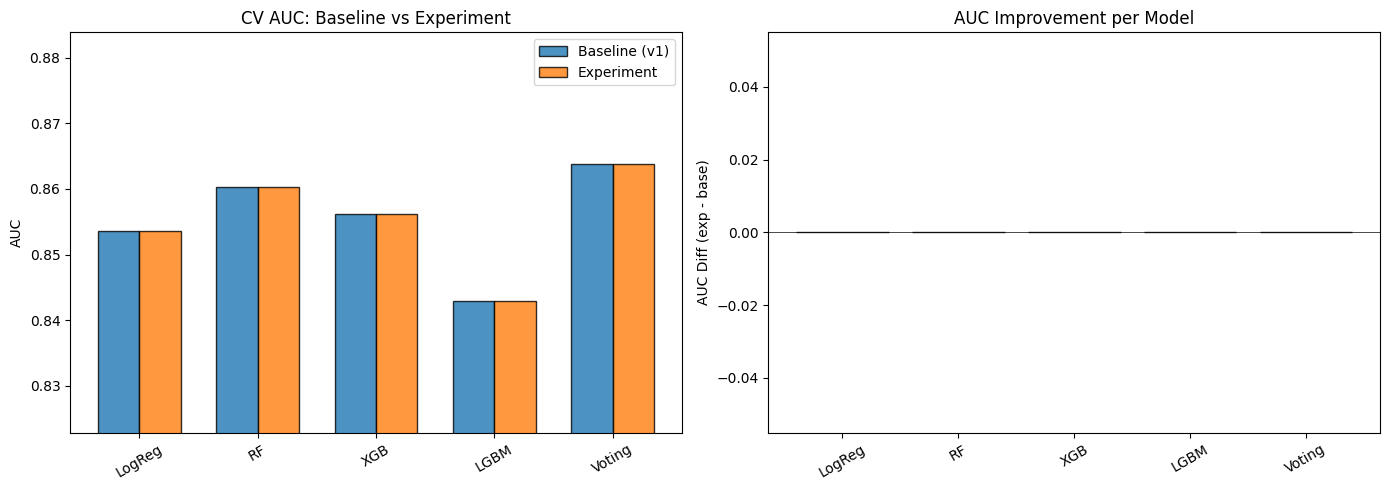

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = list(results_base.keys())
x = np.arange(len(model_names))
w = 0.35

# AUC comparison
auc_base = [results_base[m].get("auc", 0) for m in model_names]
auc_exp = [results_exp[m].get("auc", 0) for m in model_names]
axes[0].bar(x - w/2, auc_base, w, label="Baseline (v1)", alpha=0.8, edgecolor="black")
axes[0].bar(x + w/2, auc_exp, w, label="Experiment", alpha=0.8, edgecolor="black")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30)
axes[0].set_ylabel("AUC")
axes[0].set_title("CV AUC: Baseline vs Experiment")
axes[0].legend()
axes[0].set_ylim(min(min(auc_base), min(auc_exp)) - 0.02, max(max(auc_base), max(auc_exp)) + 0.02)

# AUC diff
diffs = [results_exp[m].get("auc", 0) - results_base[m].get("auc", 0) for m in model_names]
colors = ["green" if d > 0 else "red" for d in diffs]
axes[1].bar(x, diffs, color=colors, edgecolor="black", alpha=0.8)
axes[1].axhline(y=0, color="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=30)
axes[1].set_ylabel("AUC Diff (exp - base)")
axes[1].set_title("AUC Improvement per Model")

plt.tight_layout()
plt.show()

## 7. Submit Best Model

ベースラインより改善していたら、ベストモデルで提出ファイルを生成する。

In [ ]:
# Find best model by experiment AUC
best_name = max(results_exp, key=lambda m: results_exp[m].get("auc", 0))
best_auc = results_exp[best_name].get("auc", 0)
base_best_auc = max(results_base[m].get("auc", 0) for m in results_base)

print(f"Best experiment model: {best_name} (AUC={best_auc:.4f})")
print(f"Best baseline AUC: {base_best_auc:.4f}")
print(f"Improvement: {best_auc - base_best_auc:+.4f}")

if best_auc > base_best_auc:
    # Submit用: fb_exp builder で全trainデータから構築
    X_train_final, X_test_final = fb_exp(X_raw, test_raw)

    final_model = models[best_name]()
    final_model.fit(X_train_final, y)

    sample_submit = pd.read_csv(SAMPLE_SUBMIT_CSV, index_col=0, header=None)
    sample_submit[1] = final_model.predict_proba(X_test_final)[:, 1]
    sample_submit.to_csv("submit.csv", header=None)
    print(f"\nSubmission saved! (submit.csv)")
    print(f"Prediction stats: mean={sample_submit[1].mean():.3f}, std={sample_submit[1].std():.3f}")
else:
    print("\nNo improvement over baseline. Submission NOT saved.")
    print("Try different features!")